# Demographics merging (race/ethnicity from 2010 and 2020 censuses)

In [85]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [86]:
# NOTE: both tract files use the same crs
#tracts = gpd.read_file("data/philly_tracts.gpkg")

tracts = gpd.read_file("data/2010_philly_tracts/Philadelphia_Census_Tracts_2010_201302.shp")

#year = 2020
year = 2010

neighborhoods = gpd.read_file("data/philadelphia-neighborhoods.gpkg")


In [87]:
tracts.head()

,OBJECTID,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,LOGRECNO,SHAPE_AREA,SHAPE_LEN,geometry
0,46,42,101,005000,42101005000,50,Census Tract 50,G5020,S,4504459,3340294,+39.8898768,-075.1691412,10389,8.832943e+07,48033.335048,"POLYGON ((2691872.439 210170.981, 2691061.497 ..."
1,47,42,101,005400,42101005400,54,Census Tract 54,G5020,S,1846253,530013,+39.8904539,-075.2513923,10390,2.575213e+07,24624.823144,"POLYGON ((2671003.576 212565.879, 2670530.678 ..."
2,48,42,101,005500,42101005500,55,Census Tract 55,G5020,S,1168442,12010,+39.9074191,-075.2489174,10391,1.270364e+07,20389.059940,"POLYGON ((2669431.265 217950.678, 2668950.334 ..."
3,49,42,101,005600,42101005600,56,Census Tract 56,G5020,S,840411,0,+39.8988328,-075.2447347,10392,9.047139e+06,11788.147571,"POLYGON ((2672088.625 217815.518, 2672209.5 21..."
4,50,42,101,006000,42101006000,60,Census Tract 60,G5020,S,1089657,0,+39.9115196,-075.2381570,10393,1.175557e+07,14205.267812,"POLYGON ((2674346.269 221528.794, 2674543.189 ..."


In [88]:
if year == 2010: 
    tracts = tracts.rename(columns={"TRACTCE10": "TRACTCE"})


tracts.columns



Index(['OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'SHAPE_AREA', 'SHAPE_LEN',
       'geometry'],
      dtype='object')

In [89]:
tracts_sub = tracts[['TRACTCE', 'geometry']]
tracts_sub.head()

,TRACTCE,geometry
0,005000,"POLYGON ((2691872.439 210170.981, 2691061.497 ..."
1,005400,"POLYGON ((2671003.576 212565.879, 2670530.678 ..."
2,005500,"POLYGON ((2669431.265 217950.678, 2668950.334 ..."
3,005600,"POLYGON ((2672088.625 217815.518, 2672209.5 21..."
4,006000,"POLYGON ((2674346.269 221528.794, 2674543.189 ..."


In [90]:
neigh_reviews_subset = gpd.read_file("modified_data/neigh_reviews_subset.gpkg")
neigh_reviews_subset.columns

DataSourceError: modified_data/neigh_reviews_subset.gpkg: No such file or directory

In [ ]:
neigh_reviews_subset[neigh_reviews_subset.duplicated(subset="review_id")]

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,gentrified,review_id,user_id,useful,funny,cool,text,date,geometry
63359,faSi7EoZ38xMPJEpp7-pqg,Algorithm Restaurants,,Philadelphia,PA,19125,40.116933,-75.355294,5.0,10,...,None,NaN,None,None,NaN,NaN,NaN,None,None,POINT (-75.35529 40.11693)
63360,QyWxTsVvvqSEpU1KNblRbQ,Say Cheese,,Philadelphia,PA,19104,39.961333,-75.155067,4.0,34,...,Callowhill,1.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.15507 39.96133)
68396,5ogNmbqNE5U2YO_HGenGfg,Mary's Lunch,3600 Richmond St,Philadelphia,PA,19134,39.987997,-75.092056,4.5,7,...,Richmond,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.09206 39.988)
68493,FU6CaKb9hePVMAsXO5W6pw,Aya's Pizza,7144 Elmwood Ave,Philadelphia,PA,19142,39.915063,-75.240049,2.5,30,...,Elmwood,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.24005 39.91506)
88462,2X3sYDb2wORzDDwNZP33WA,Flaming Basil,,Philadelphia,PA,19104,39.958359,-75.195393,4.0,12,...,University City,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.19539 39.95836)
89877,VOBvxu8SzLGSun8o5OFhjA,QT Vietnamese Sandwich,,Philadelphia,PA,19104,39.955887,-75.193410,4.0,6,...,University City,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.19341 39.95589)
94749,F48wjJ_jjEz59Prh20XhRA,Tyson Bees,,Philadelphia,PA,19104,39.959169,-75.198419,3.5,147,...,University City,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.19842 39.95917)
106052,cGHnqrUiSMW8aMJ9mg8e1g,Abbraccio,820 S 47th St,Philadelphia,PA,19143,39.948344,-75.216797,2.5,14,...,Cedar Park,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.2168 39.94834)
116052,5N9nJbymj9JtOAEx6ZMxpg,The Spot Food Truck,,Philadelphia,PA,19104,39.951360,-75.184697,4.5,50,...,University City,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.1847 39.95136)
130927,jpqSJnoaIOggsFHV8bOXyw,Level 33,1200 Market St,Philadelphia,PA,19107,39.951784,-75.160194,2.0,7,...,Washington Square West,0.0,None,None,NaN,NaN,NaN,None,None,POINT (-75.16019 39.95178)


In [ ]:
neigh_reviews_subset = neigh_reviews_subset.drop('index_right', axis=1)
neigh_reviews_subset = neigh_reviews_subset.to_crs(tracts.crs)
neigh_reviews_subset.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
neigh_reviews_subset.shape

(682950, 24)

In [ ]:
# reviews joined with location info (neighborhood, tract)
reviews_loc = (
    gpd.sjoin(
        neigh_reviews_subset,
        tracts_sub[['TRACTCE', 'geometry']],
        how='left',
        predicate='within'   
    )
    .drop(columns='index_right')
)
reviews_loc.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,gentrified,review_id,user_id,useful,funny,cool,text,date,geometry,TRACTCE
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),000200
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (2695729.449 237331.978),000200
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (2695729.449 237331.978),000200
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (2695729.449 237331.978),000200
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (2695729.449 237331.978),000200


In [ ]:
reviews_loc = reviews_loc.drop_duplicates(subset="review_id")

reviews_loc.shape[0] / neigh_reviews_subset.shape[0]

0.9999267881982575

In [ ]:
reviews_loc.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,gentrified,review_id,user_id,useful,funny,cool,text,date,geometry,TRACTCE
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (2695729.449 237331.978),000200
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (2695729.449 237331.978),000200
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (2695729.449 237331.978),000200
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (2695729.449 237331.978),000200
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (2695729.449 237331.978),000200


In [ ]:
len(reviews_loc['TRACTCE'].unique())

345

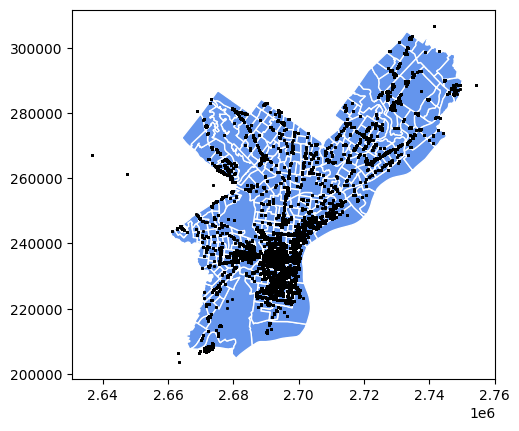

In [ ]:

ax = tracts.plot(color="cornflowerblue",edgecolor="white")
reviews_loc.plot(ax=ax, markersize= 1, color="black", alpha=0.6)
plt.show()

## Merge with race and ethnicity data 

In [ ]:
reviews_loc.dtypes

business_id        object
name               object
address            object
city               object
state              object
postal_code_x      object
latitude          float64
longitude         float64
stars             float64
review_count        int64
is_open             int64
attributes         object
categories         object
hours              object
LISTNAME           object
gentrified        float64
review_id          object
user_id            object
useful            float64
funny             float64
cool              float64
text               object
date               object
geometry         geometry
TRACTCE            object
dtype: object

In [ ]:
#race = pd.read_csv("modified_data/race_ethn_cleaned_2020.csv")
race = pd.read_csv("modified_data/race_ethn_cleaned_2010.csv")
reviews_loc['TRACTCE'] = reviews_loc['TRACTCE'].astype(str).str.zfill(6)
race['TRACTCE'] = race['TRACTCE'].dropna().astype(int).astype(str).str.zfill(6)
reviews_demog = pd.merge(reviews_loc, race, how="left", on="TRACTCE")
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,geometry,TRACTCE,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,POINT (2695729.449 237331.978),000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,POINT (2695729.449 237331.978),000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,POINT (2695729.449 237331.978),000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,POINT (2695729.449 237331.978),000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,POINT (2695729.449 237331.978),000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623


In [ ]:
reviews_demog.shape[0]

682900

In [91]:
reviews_demog = reviews_demog.rename(columns={"LISTNAME": "neighborhood"})

In [94]:
# nobody lives in the Airport neighborhood
demog_vars = ['tot_pop', 'prop_black', 'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only']
tract_980400 = reviews_demog[reviews_demog[demog_vars].isnull().any(axis=1)]
tract_980400['neighborhood']

reviews_demog = reviews_demog.dropna(subset=demog_vars)

### Create demographic indicators

In [95]:
neighborhoods = neighborhoods.to_crs(reviews_demog.crs)
neighborhoods = neighborhoods.rename(columns={"LISTNAME": "neighborhood"})

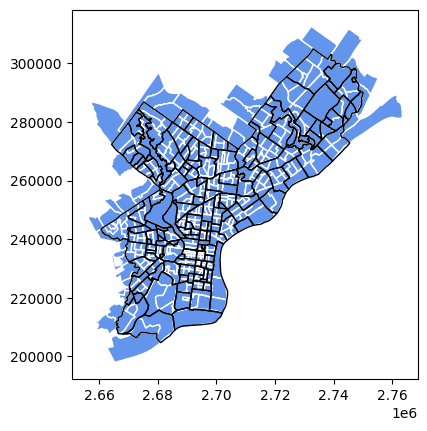

In [45]:
ax = tracts.plot(color="cornflowerblue",edgecolor="white")
neighborhoods.plot(ax=ax, facecolor="none", edgecolor="black", alpha=1)
plt.show()

In [96]:
tract_neigh_intersection = gpd.overlay(tracts_sub, neighborhoods, how="intersection")
tract_neigh_intersection['overlap_area'] = tract_neigh_intersection.geometry.area

In [97]:
tract_neigh_intersection.head()

,TRACTCE,NAME,neighborhood,MAPNAME,Shape_Leng,Shape_Area,geometry,overlap_area
0,005000,RIVERFRONT,Riverfront,Riverfront,47425.508833,6.283839e+07,"POLYGON ((2698736.359 215756.296, 2699070.781 ...",1.912337e+06
1,005000,INDUSTRIAL,Industrial,Industrial,53290.782918,1.194374e+08,"MULTIPOLYGON (((2684961.438 214396.112, 268495...",2.215785e+06
2,005000,AIRPORT,Airport,Airport,49698.191521,9.773868e+07,"MULTIPOLYGON (((2685640.463 209988.181, 268578...",6.094569e+04
3,005000,STADIUM_DISTRICT,Stadium District,Stadium District,37632.285929,7.069352e+07,"POLYGON ((2690899.589 216411.917, 2691152.738 ...",1.805822e+06
4,005000,NAVY_YARD,Navy Yard,Navy Yard,42694.549644,8.018157e+07,"POLYGON ((2685568.119 211010.509, 2685458.605 ...",7.850832e+07


In [98]:
reviews_demog = reviews_demog.merge(
    tract_neigh_intersection[['TRACTCE', "neighborhood", "overlap_area"]],
    on=['TRACTCE', "neighborhood"],
    how="left"
)
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,TRACTCE,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,overlap_area
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,000200,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06


In [99]:
reviews_demog = reviews_demog.drop_duplicates(subset=['review_id', 'TRACTCE'])
reviews_demog.shape[0]

677142

In [100]:
# find tracts that are predominantly POC
# get weighted proportion white only for each neighborhood
weighted_white = (
    reviews_demog
    .groupby("neighborhood")
    .apply(lambda x: (x["prop_white_only"] * x["overlap_area"]).sum() / x["overlap_area"].sum())
    .reset_index(name="prop_white_wavg")
)

weighted_white

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_93138/3631529231.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["prop_white_only"] * x["overlap_area"]).sum() / x["overlap_area"].sum())


,neighborhood,prop_white_wavg
0,Academy Gardens,0.822102
1,Airport,0.233333
2,Allegheny West,0.134066
3,Andorra,0.811654
4,Aston-Woodbridge,0.619952
...,...,...
143,Wister,0.052210
144,Woodland Terrace,0.160084
145,Wynnefield,0.170252
146,Wynnefield Heights,0.192135


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  3.,  0.,
         1.,  9., 18.,  9.,  7.,  6.,  5.,  5.,  2.,  4.,  4.,  3.,  1.,
         1.,  2.,  1.,  4.,  2.,  3.,  4.,  6.,  1.,  3.,  3.,  3.,  2.,
         3.,  2.,  5.,  8.,  5.,  5.,  4.,  0.,  0.,  1.,  1.]),
 array([-0.41062308, -0.38241062, -0.35419816, -0.3259857 , -0.29777324,
        -0.26956078, -0.24134831, -0.21313585, -0.18492339, -0.15671093,
        -0.12849847, -0.10028601, -0.07207354, -0.04386108, -0.01564862,
         0.01256384,  0.0407763 ,  0.06898876,  0.09720123,  0.12541369,
         0.15362615,  0.18183861,  0.21005107,  0.23826353,  0.266476  ,
         0.29468846,  0.32290092,  0.35111338,  0.37932584,  0.4075383 ,
         0.43575077,  0.46396323,  0.49217569,  0.52038815,  0.54860061,
         0.57681307,  0.60502554,  0.633238  ,  0.66145046,  0.68966292,
         0.71787538,  0.74608784,  0.77430031,  0.80251277,  0.83072523,
         0.85893769,  0.88715015,  0.91536261,  0.94357508,

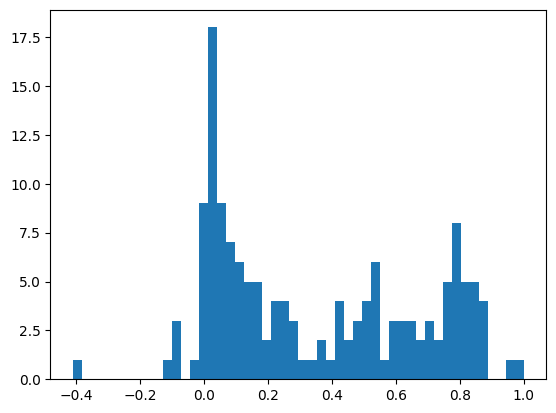

In [101]:
plt.hist(weighted_white['prop_white_wavg'], bins=50)

In [102]:
reviews_demog = pd.merge(reviews_demog,weighted_white,  how="left", on="neighborhood")
reviews_demog.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,Unnamed: 0,geography,geographic_area_name,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,overlap_area,prop_white_wavg
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06,-0.410623
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06,-0.410623
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06,-0.410623
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06,-0.410623
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,1.0,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2937.0,0.102826,1.280899,0.026898,-0.410623,1.243673e+06,-0.410623


In [103]:
reviews_demog.shape[0]

677142

In [104]:
reviews_demog['predom_poc'] = np.where(reviews_demog['prop_white_wavg'] < 0.4, 1, 0)
reviews_demog['no_predom_race'] = np.where((reviews_demog['prop_white_wavg'] > 0.4) & (reviews_demog['prop_white_wavg'] < 0.6), 1, 0)

In [105]:
reviews_demog.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry', 'TRACTCE', 'Unnamed: 0', 'geography',
       'geographic_area_name', 'tot_pop', 'prop_black', 'prop_asian',
       'prop_hispanic_or_latino', 'prop_white_only', 'overlap_area',
       'prop_white_wavg', 'predom_poc', 'no_predom_race'],
      dtype='object')

In [ ]:
reviews_demog.shape[0] - neigh_reviews_subset.shape[0] # that's fine, we dropped busineses w/ no reviews
# in 2010: dropped airport reviews

-5808

In [107]:

reviews_demog = reviews_demog.drop(columns=["Unnamed: 0", "geography"])

reviews_demog.to_file(f"modified_data/reviews_demog_{year}.gpkg")


## Descriptive stats + exploration

In [108]:
pd.crosstab(reviews_demog['predom_poc'], reviews_demog['gentrified'], normalize=True)

gentrified,0.0,1.0
predom_poc,,
0,0.675931,0.08249
1,0.229289,0.01229


In [109]:
pd.crosstab(reviews_demog['no_predom_race'], reviews_demog['gentrified'], normalize=True)

gentrified,0.0,1.0
no_predom_race,,
0,0.470225,0.068988
1,0.434994,0.025793


In [110]:
# gentrified predominantly POC neighborhoods (> 60% nonwhite)
gentrified_poc = reviews_demog[(reviews_demog['predom_poc'] == 1) & (reviews_demog['gentrified'] == 1)]
poc_gentrified_neighborhoods = gentrified_poc['neighborhood'].unique()
poc_gentrified_neighborhoods

array(['Callowhill', 'Olney', 'Cobbs Creek', 'Mount Airy, East',
       'Southwest Schuylkill'], dtype=object)

In [111]:
# gentrified predominantly white neighborhoods (< 40% nonwhite)
gentrified_white = reviews_demog[(reviews_demog['predom_poc'] == 0) & (reviews_demog['no_predom_race'] == 0) & (reviews_demog['gentrified'] == 1)]
white_gentrified_neighborhoods = gentrified_white['neighborhood'].unique()
white_gentrified_neighborhoods

array(['Fishtown - Lower Kensington', 'Roxborough', 'East Falls',
       'Fairmount', 'Upper Roxborough', 'Roxborough Park'], dtype=object)

In [112]:
# gentrified mixed race neighborhoods (between 40% and 60% nonwhite)
gentrified_mixed = reviews_demog[(reviews_demog['no_predom_race'] == 1) & (reviews_demog['gentrified'] == 1)]
mixed_gentrified_neighborhoods = gentrified_mixed['neighborhood'].unique()
mixed_gentrified_neighborhoods

array(['Logan Square'], dtype=object)